In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root

s = Simulation()
N_t = 250
tg = 250
tlist = np.linspace(0, tg, N_t)
sigma = 0.2

# compute cos params
cos_amp, cos_wd = compute_cos_params(s, tg)
heff_params = s.heff(cos_wd, cos_amp)
Delta = heff_params[2][2] - heff_params[0][0]
# rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos dirve case
rrr, Delta
print("wd: " , cos_wd)

wd:  4.441197348211455


In [2]:
s.sorted_evals[1,0,0]

np.float64(23.87584256065368)

In [3]:
s.sorted_evals[0,1,0]

np.float64(27.140189266364587)

In [4]:
s.sorted_evals[0,0,1]

np.float64(19.437799274233825)

In [5]:
(27.140189266364587-19.437799274233825)/cos_wd

np.float64(1.7343048255292335)

In [6]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg, use_drag=True):
    ht, ht_args = h_target(Delta, rrr, tg, use_drag = use_drag, sigma_r = sigma)
    return ht, ht_args
ht, args = compute_htarget(tg)

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


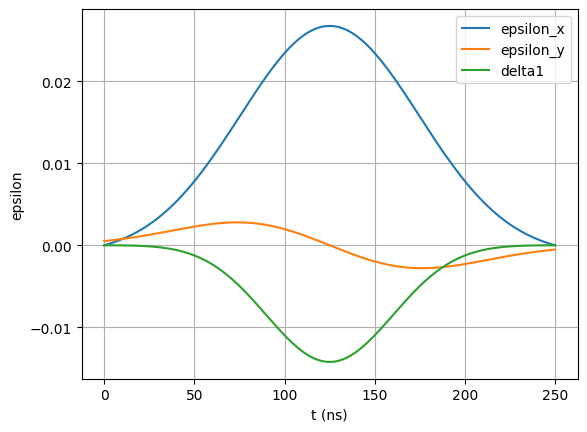

In [7]:
ex = np.array([args[0](t) for t in tlist])
ey = np.array([args[1](t)*10 for t in tlist])
d1 = np.array([args[2](t) for t in tlist])
plt.figure()
plt.plot(tlist, ex, label='epsilon_x')
plt.plot(tlist, ey, label='epsilon_y')
plt.plot(tlist, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


Also we use a normal effective hamiltonian for cos drive to compensate compare

100%|██████████| 20/20 [00:00<00:00, 20.53it/s]


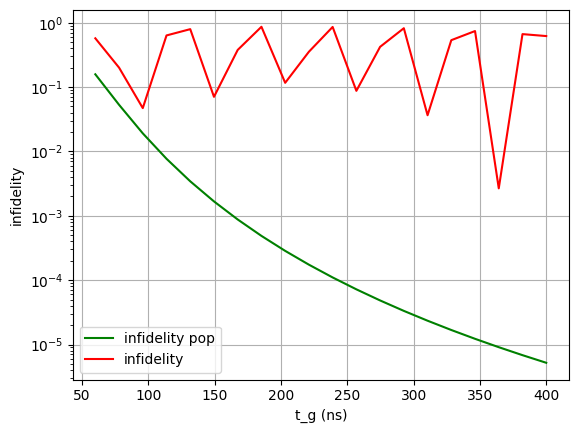

In [8]:
def plot_tg_fid_curve(hamiltonian_function, n, tg_min = 60, tg_max = 400):
    lf_pop = []
    lf = []
    ltg = np.linspace(tg_min, tg_max, n)
    for tg in tqdm(ltg):
        h, _ = hamiltonian_function(tg)
        tlist = np.linspace(0, tg, N_t)
        f = extract_fidelity(h, tlist)
        fpop = extract_pop_fid(h, tlist)['iswap_fidelity']
        lf_pop.append(1-fpop)
        lf.append(1-f)
    ax = plt.subplot()
    plt.plot(ltg, lf_pop, label='infidelity pop', color='green')
    plt.plot(ltg, lf, label='infidelity', color='red')
    plt.xlabel('t_g (ns)')
    plt.ylabel('infidelity')
    ax.set_yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_tg_fid_curve(compute_htarget, 20)

After verifying the fidelity of the target-hamiltonian, now the target hamiltonian must be achieved by a given time-dependant pulse-shape that is applied to the coupler

In [9]:
import pickle
from pathlib import Path
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.7 * 2*np.pi, 0.712 * 2*np.pi] # TODO anpassen
amp_real_max = 1.0 * 2 * np.pi
amp_imag_max = amp_real_max / 8
amp_real_range = (-amp_real_max, amp_real_max)
amp_imag_range = (-amp_imag_max, amp_imag_max)

# Load coefficients
with open(coeff_file, 'rb') as f:
    coefficients_data = pickle.load(f)
coeffs01 = coefficients_data['coeffs01']
coeffs00 = coefficients_data['coeffs00']
coeffs11 = coefficients_data['coeffs11']
# coeffs12 = coefficients_data['coeffs12']
coeffs22 = coefficients_data['coeffs22']
# coeffs02 = coefficients_data['coeffs02']
print(f"Coefficients loaded from {coeff_file}")

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = [1, wd, ar, ai, wd**2, ar**2, ai**2,
                wd*ar, wd*ai, ar*ai]
    if not len(coeffs) == 10:
        x.extend([
            wd**3, ar**3, ai**3,
            wd**2*ar, wd**2*ai,
            wd*ar**2, wd*ai**2,
            ar**2*ai, ar*ai**2,
            wd*ar*ai])
    return np.array(x) @ coeffs

Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


setup the functions that are used to optimize the 3 independent parameters wd, amp_r and amp_i for achieving max compliance with the target hamiltonian. 

In [10]:
from scipy.optimize import least_squares

def find_parameter_change_fit(wd0, heff_t, prev_solution):
    if not prev_solution:
        prev_solution = [0,0,0]
    def residuals(x):
        dw, ar, ai = x
        wd = wd0 + dw
        amp = ar + 1j*ai 

        deltadiff = (heff_fit(coeffs00, wd, amp) - heff_fit(coeffs11, wd, amp)) - (heff_t[0,0] - heff_t[1,1])
        # deltadiff2 = (heff_fit(coeffs11, wd, amp) - heff_fit(coeffs22, wd, amp)) - (heff_t[1,1] - heff_t[2,2])
        omega_diff = heff_fit(coeffs01, wd, amp) - heff_t[0,1]

        weights = np.array([1,
                            1,
                            1,])
        return weights*np.array([
            abs(deltadiff),
            np.real(omega_diff),
            np.imag(omega_diff)])
    dwd_range = (-1,1)
    res = least_squares(residuals, x0=[prev_solution[0], prev_solution[1], prev_solution[2]], 
                        bounds=([wd_range[0] - wd0, amp_real_range[0], amp_imag_range[0]], 
                                [wd_range[1] - wd0, amp_real_range[1], amp_imag_range[1]]))
    return {"dw": res.x[0], "dar": res.x[1], "dai": res.x[2]}

from scipy.optimize import minimize
def find_parameters_error(wd0, heff_t, prev_solution):
    lambda_leak = 1
    def objective(x):
        dw, ar, ai = x
        wd = wd0 + dw
        amp = ar + 1j*ai

        deltadiff = (
            heff_fit(coeffs00, wd, amp)
            - heff_fit(coeffs11, wd, amp)
        ) - (heff_t[0,0] - heff_t[1,1])

        deltadiff2 = (
            heff_fit(coeffs11, wd, amp)
            - heff_fit(coeffs22, wd, amp)
        ) - (heff_t[1,1] - heff_t[2,2])

        omega_diff = heff_fit(coeffs01, wd, amp) - heff_t[0,1]
        omega2_diff = heff_fit(coeffs12, wd, amp) - heff_t[1,2]
        omega3_diff = heff_fit(coeffs02, wd, amp) - heff_t[0,2]

        return (
            abs(deltadiff) * 2
            + abs(omega_diff)
            + abs(omega2_diff)
            + abs(omega3_diff)
            - lambda_leak * np.real(deltadiff2)
        )
    res = minimize(
        objective,
        x0=[0, 0, 0],
        bounds=[(-1,1),amp_real_range,amp_imag_range],method="L-BFGS-B")
    result = {"dw": res.x[0],"dar": res.x[1],"dai": res.x[2]}
    return result

# define a function to change the list representation of h_target to one time dependant matrix function
def sum_list(ht):
    def f(t):
        result = ht[0]
        for i in range(1, len(ht)):
            result = result + ht[i][0] * ht[i][1](t)
        return result
    return f

setup the heff_modulated method and test hamiltonian compliance with one example

In [11]:
ht, _ = compute_htarget(tg)
ht_func = sum_list(ht)
wd0 = s.find_resonance(0)
def heff_modulated(t, args=None):
    res = find_parameter_change_fit(wd0, ht_func(t), None)
    dw = res['dw']
    da = res['dar'] + 1j*res['dai']
    return Qobj(s.heff(wd0 + dw.real, da))
    
# for some examples, show if the hamiltonian comes close to the target
tt = 200
print("h0: ")
print("heff_modulated: ")
h_mod = heff_modulated(tt)
# for i in range(0,2):
#     h_mod[i][i] -= h_mod[0][0]
display(h_mod)
print("htarget: ")
display(ht_func(tt))

h0: 
heff_modulated: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.10691095e-04+0.00000000e+00j  3.91215250e-03+1.13609047e-04j
  -7.51549758e-04-4.36869052e-05j]
 [ 3.91215250e-03-1.13609047e-04j -1.35256859e-03+0.00000000e+00j
   3.91628795e-02+1.13729140e-03j]
 [-7.51549758e-04+4.36869052e-05j  3.91628795e-02-1.13729140e-03j
  -1.17570844e+00+0.00000000e+00j]]

htarget: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.        +0.j          0.00391148+0.00011437j  0.        +0.j        ]
 [ 0.00391148-0.00011437j -0.00124188+0.j          0.03909483+0.00114313j]
 [ 0.        +0.j          0.03909483-0.00114313j -1.17894013+0.j        ]]

drive_signal_func gives the time dependant DRAG amplitude 

mesolve cannot deal with the difficult heff_modulated / pulse_shape_modulated functions as a parameter, so instead we precompute values and then simply interpolate between the defined values.

In [12]:
force_computation = True
heff_file = coeff_dir / 'precomputed_heff_modulated.pkl'
drive_freq_precomputed = []
drive_amp_real_precomputed = []
drive_amp_imag_precomputed = []

if heff_file.exists() and not force_computation:
    with open(heff_file, 'rb') as f:
        heff_data = pickle.load(f)
    print(f"heff_modulated loaded from {heff_file}")
    drive_freq_precomputed = heff_data['frequency']
    drive_amp_real_precomputed = heff_data['amplitude_real']
    drive_amp_imag_precomputed = heff_data['amplitude_imag']
else:
    prev_sol = None
    for t in tqdm(tlist):
        res = find_parameter_change_fit(wd0, ht_func(t), prev_solution=prev_sol)
        freq= wd0 + res['dw']
        amp_real = res['dar']
        amp_imag = res['dai']
        drive_freq_precomputed.append(freq)
        drive_amp_real_precomputed.append(amp_real)
        drive_amp_imag_precomputed.append(amp_imag)
        prev_sol = [res['dw'], amp_real, amp_imag]
    
    drive_freq_precomputed = np.array(drive_freq_precomputed)
    drive_amp_real_precomputed = np.array(drive_amp_real_precomputed)
    drive_amp_imag_precomputed = np.array(drive_amp_imag_precomputed)
    heff_data = {
        'frequency': drive_freq_precomputed,
        'amplitude_real': drive_amp_real_precomputed,
        'amplitude_imag': drive_amp_imag_precomputed
    }
    with open(heff_file, 'wb') as f:
        pickle.dump(heff_data, f)
    print(f"frequency and amplitudes saved to {heff_file}")

100%|██████████| 250/250 [00:00<00:00, 2596.43it/s]

frequency and amplitudes saved to /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated.pkl


In [13]:
def drive_wd_interp(t, args=None):
    if t <= tlist[0]:
        return drive_freq_precomputed[0]
    if t >= tlist[-1]:
        return drive_freq_precomputed[-1]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    return (1 - alpha) * drive_freq_precomputed[idx] + alpha * drive_freq_precomputed[idx + 1]

def drive_amp_interp(t, args=None):
    if t <= tlist[0]:
        return 0
        return drive_amp_real_precomputed[0] + 1j*drive_amp_imag_precomputed[0] 
    if t >= tlist[-1]:
        return 0
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    amp_real = (1 - alpha) * drive_amp_real_precomputed[idx] + alpha * drive_amp_real_precomputed[idx + 1]
    amp_imag = (1 - alpha) * drive_amp_imag_precomputed[idx] + alpha * drive_amp_imag_precomputed[idx + 1]
    return amp_real + 1j*amp_imag

def drive_signal_interp(t, args=None):
    return drive_amp_interp(t) * np.cos(drive_wd_interp(t) * t)

def heff_mod_build(t, args=None):
    wd = drive_wd_interp(t)
    a = drive_amp_interp(t)
    return Qobj(s.heff(wd, a))

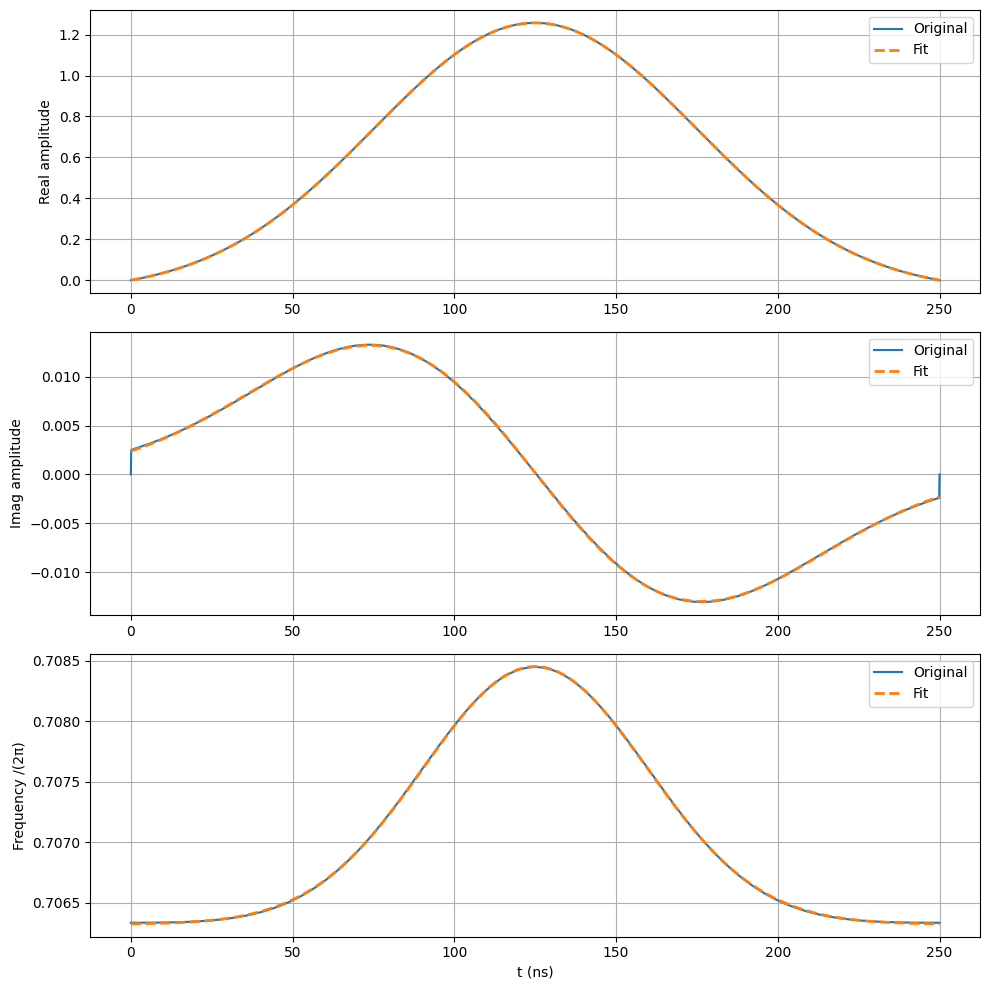

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sympy as sp

def gaussian(t, A, t0, sigma, c):
    return c + A*np.exp(-(t-t0)**2/(2*sigma**2))

def gaussian_sine(t, A, t0, sigma, omega, phi, c):
    return c + A*np.sin(omega*(t-t0)+phi)*np.exp(-(t-t0)**2/(2*sigma**2))


def plot_drive_components_with_fit(t_end=tg, n=2000):

    # ------------------------------------------------------------------
    # Daten
    # ------------------------------------------------------------------

    t_vals = np.linspace(0, t_end, n)

    amp_real = np.array([drive_amp_interp(t).real for t in t_vals])
    amp_imag = np.array([drive_amp_interp(t).imag for t in t_vals])
    freq = np.array([drive_wd_interp(t) for t in t_vals])

    # ------------------------------------------------------------------
    # Startwerte
    # ------------------------------------------------------------------

    t0_guess = t_vals[np.argmax(np.abs(amp_real))]
    sigma_guess = t_end/6

    # Reelle Amplitude
    p0_real = [
        amp_real.max()-amp_real.min(),
        t0_guess,
        sigma_guess,
        np.mean(amp_real[:50])
    ]

    # Imaginäre Amplitude
    idx = np.argmax(np.abs(amp_imag))
    t0_imag = t_vals[idx]

    p0_imag = [
        np.max(np.abs(amp_imag)),
        t0_imag,
        sigma_guess,
        2*np.pi/t_end,
        0.0,
        0.0
    ]

    # Frequenz
    idx = np.argmax(freq)
    t0_freq = t_vals[idx]

    p0_freq = [
        freq.max()-freq.min(),
        t0_freq,
        sigma_guess,
        np.min(freq)
    ]

    # ------------------------------------------------------------------
    # Fits
    # ------------------------------------------------------------------

    popt_real, _ = curve_fit(
        gaussian,
        t_vals,
        amp_real,
        p0=p0_real,
        maxfev=20000
    )
    popt_imag, _ = curve_fit(
        gaussian_sine,
        t_vals,
        amp_imag,
        p0=p0_imag,
        maxfev=50000
    )
    popt_freq, _ = curve_fit(
        gaussian,
        t_vals,
        freq,
        p0=p0_freq,
        maxfev=20000
    )
    real_fit = gaussian(t_vals, *popt_real)
    imag_fit = gaussian_sine(t_vals, *popt_imag)
    freq_fit = gaussian(t_vals, *popt_freq)

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------

    fig, axes = plt.subplots(3,1,figsize=(10,10))

    axes[0].plot(t_vals, amp_real, label="Original")
    axes[0].plot(t_vals, real_fit, "--", linewidth=2, label="Fit")
    axes[0].set_ylabel("Real amplitude")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t_vals, amp_imag, label="Original")
    axes[1].plot(t_vals, imag_fit, "--", linewidth=2, label="Fit")
    axes[1].set_ylabel("Imag amplitude")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(t_vals, freq/(2*np.pi), label="Original")
    axes[2].plot(t_vals, freq_fit/(2*np.pi), "--", linewidth=2, label="Fit")
    axes[2].set_ylabel("Frequency /(2π)")
    axes[2].set_xlabel("t (ns)")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # SymPy-Ausdrücke
    # ------------------------------------------------------------------

    A, t0, sigma, c = popt_real
    amp_sym_real = lambda t: (c + A*sp.exp(-(t-t0)**2/(2*sigma**2)))
    A, t0, sigma, omega, phi, c = popt_imag
    amp_sym = lambda t: amp_sym_real(t) + 1j*(c + A * sp.sin(omega*(t-t0)+phi) * sp.exp(-(t-t0)**2/(2*sigma**2)))
    A, t0, sigma, c = popt_freq
    freq_sym = lambda t: c + A*sp.exp(-(t-t0)**2/(2*sigma**2))
    return amp_sym, freq_sym, popt_real, popt_imag, popt_freq


amp_sym, freq_sym, p_real, p_imag, p_freq = plot_drive_components_with_fit()

with the heff_modulated_interp function, the extraction of fidelity measurements can be done fast. To test for the right adoption of h_target, we compare fidelities for h_t, h_modulated and the raw hamiltonian with the given drive signal (h_drive). In the following those 3 cases will correspond to the values fid_engineered, fid_modulated, fid_drive.

In [15]:
# simulate the result directly over H0 and V1 from s 
tlist_fid = np.linspace(0, tg, 2500)
lh = [s.H0, [s.V1, drive_signal_interp]]

# f_d = extract_fidelity(lh, tlist_fid, sim=s)
# fpop_d = extract_pop_fid(lh, tlist_fid, plot=True, plot_c=True, s=s)['iswap_fidelity']
# print(f"infidelity driven: pop: {(1-fpop_d):.2e}, normal:  {1-f_d:.2e}")

# modulated
print("modulated")
def heff_modulated_interp(t, args=None):
    wd = drive_wd_interp(t)
    amp = drive_amp_interp(t)
    return Qobj(s.heff(wd, amp))
# f_m = extract_fidelity(heff_modulated_interp, np.linspace(0,tg,2500), debug=True ,plot=False)
# fpop_m = extract_pop_fid(heff_modulated_interp, tlist_low, debug=False,plot=True, plot_c = True)['iswap_fidelity']
# print(f"infidelity modulated pop: {(1-fpop_m):.2e}")


modulated


Before moving on with the investigation fo the unitary transformations. Let's verify, that Floquet Theory can't predict the detune effect, observed in the direct simulation. The expectation is for the detune to be absent with the floquet prediction, because population exchange in the sambe space doesn't show any such problems. Thus the normal population, which is directly proportional at $t=t_g$ should follow this example. 

In [ ]:
# get the unitary that is predicted by floquet theory
# lU = unitary_evolution(tlist, drive_wd_interp, drive_amp_interp, s.E_array,
#                         s.V1_dressed_array, s.state_a, s.state_b, s.state_c)
initial_state = np.zeros(27)
initial_state[s.state_a] = 1
psi_t_rHeff2_rW0, lUad = Psi_t_FloquetPerturb_dynamic(
    2,
    0,
    drive_wd_interp,
    drive_amp_interp,
    s.resonances, # E_state_a - wd = E_state_b = E_state_c - 2*wd
    s.E_array,
    s.V1_dressed_array,
    initial_state,
    tlist,
)

psi_t_rHeff2_rW0, lUnum = Psi_t_FloquetPerturb_dynamic2(
    2,
    0,
    drive_wd_interp,
    drive_amp_interp,
    s.resonances, # E_state_a - wd = E_state_b = E_state_c - 2*wd
    s.E_array,
    s.V1_dressed_array,
    initial_state,
    tlist,
)
# test the propagator
M = np.zeros((3,3,len(tlist)), dtype=complex)
for it in range(len(tlist)):
    M[:,:,it]=lUnum[:,:,it].conj().T @ lUad[:,:,it]
display(Qobj(M[:,:,200]))



250it [00:00, 336.67it/s]
250it [00:00, 573.84it/s]


array([[ 6.67898053e-01+2.33188941e-01j,  6.60172989e-01-2.52399885e-01j,
         9.89467095e-04-2.28273344e-04j],
       [-6.60244071e-01-2.52214496e-01j,  6.67833040e-01-2.33376494e-01j,
        -2.04375722e-04-1.24794170e-04j],
       [-6.79667009e-04-5.11222516e-04j, -5.82314320e-04-1.61589605e-04j,
         9.76393393e-01+2.15997348e-01j]])

/var/folders/7k/3h2gl4fs7gb1hdzh7fl2mc940000gn/T/ipykernel_41029/2117203315.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


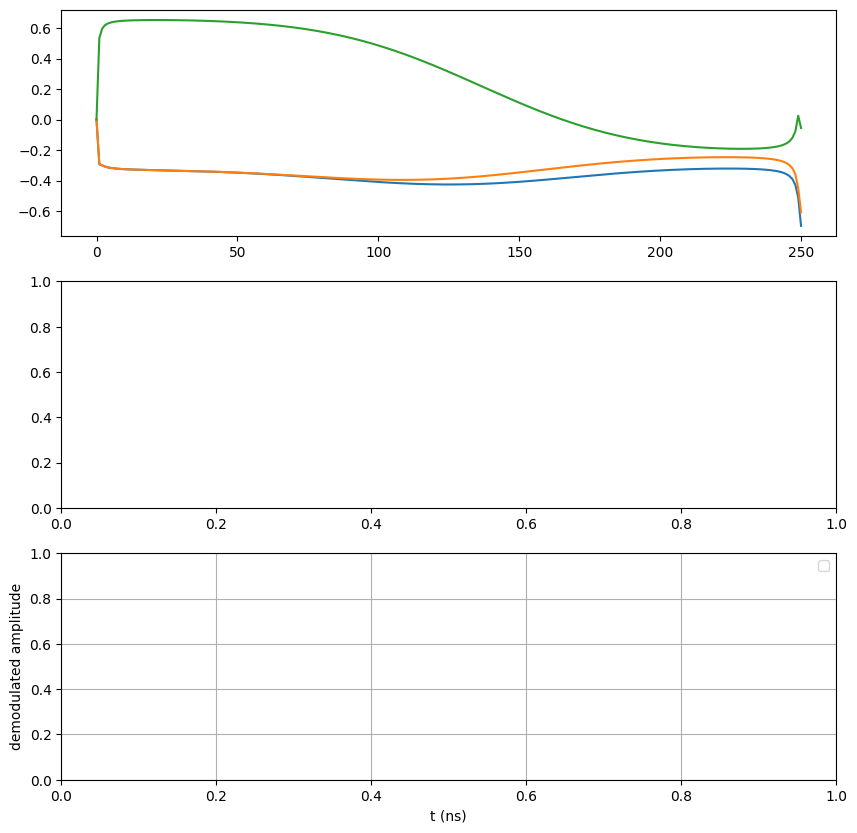

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# show the unitary evolution at 00, 11 and 01 for the target evolution and the actual evolution
axes[0].plot(tlist, lUad[0,0,:]-lUnum[0,0,:], label="00")
axes[0].plot(tlist, lUad[1,1,:]-lUnum[1,1,:], label="11")
axes[0].plot(tlist, lUad[0,1,:]-lUnum[0,1,:], label="01")
# axes[0].plot(tlist, ud_01, label="ud_01")
# axes[1].plot(tlist, uf_00-uf_11, label="uf_delta")
# axes[1].plot(tlist, uf_01, label="uf_01")

def demodulated_amplitude(signal, t_vals):
    wd_vals = np.array([drive_wd_interp(t) for t in t_vals])
    phi = np.zeros_like(t_vals)
    phi[1:] = np.cumsum(0.5 * (wd_vals[:-1] + wd_vals[1:]) * np.diff(t_vals))
    envelope = signal * np.exp(1j * phi)
    return np.sqrt(np.real(envelope)**2 + np.imag(envelope)**2)

# ud_delta = ud_00 - ud_11
# am_ud_delta = demodulated_amplitude(ud_delta, tlist_fid)
# am_ud_01 = demodulated_amplitude(ud_01, tlist_fid)

# axes[2].plot(tlist, ud_01-uf_01, label='amplitude deviance rr')
# axes[2].plot(tlist, (ud_00-ud_11)-(uf_00-uf_11), label='amplitude deviance dd')
# ax_amp.plot(tlist_fid, am_ud_delta, label='amplitude(ud_00-ud_11)')
# ax_amp.plot(tlist_fid, am_ud_01, label='amplitude(ud_01)')
axes[2].set_xlabel('t (ns)')
axes[2].set_ylabel('demodulated amplitude')
axes[2].grid(True)
axes[2].legend()
plt.show()


4.017564e-03


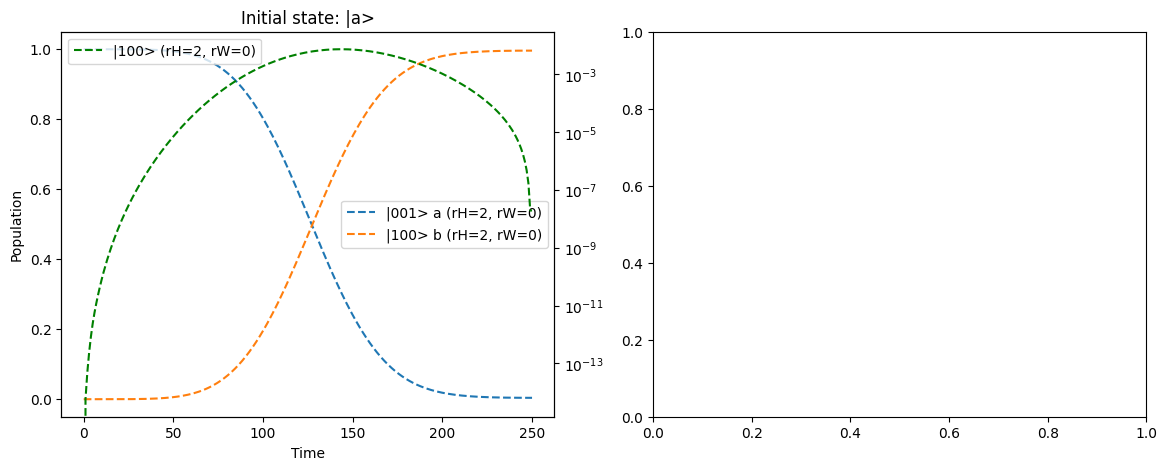

In [18]:
fix, axes = plt.subplots(1,2, figsize = (14,5))
# each column in the unitary represents one initial state U(row;column)
def plot_for_i(i,):
    # axes[i].plot(tlist, np.abs(lU[:,0,i])**2, label='population a')
    # axes[i].plot(tlist, np.abs(lU[:,1,i])**2, label='population b')
    axes[i].plot(tlist, np.abs(psi_t_rHeff2_rW0[s.state_a, :]) ** 2, "--",label="|001> a (rH=2, rW=0)",)
    axes[i].plot(tlist, np.abs(psi_t_rHeff2_rW0[s.state_b, :]) ** 2, "--",label="|100> b (rH=2, rW=0)",)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Population')
    title = 'Initial state: |a>' if i==0 else 'Initial state: |b>'
    axes[i].set_title(title)
    axes[i].legend()
    # plot the leakage population on a log-scale
    axc = axes[i].twinx()
    axc.semilogy(tlist, np.abs(psi_t_rHeff2_rW0[s.state_c, :]) ** 2, "--",label="|100> (rH=2, rW=0)",color = 'green')
    # axc.semilogy(tlist, np.abs(lU[:,2,i])**2, label='population c (log)', color='green')
    axc.legend()
    axc.plot()
plot_for_i(0)
# plot_for_i(1)
# fidelity
fid = 1- np.abs(psi_t_rHeff2_rW0[s.state_b, -1]) ** 2
print(f"{fid:1e}")

Apparently, the detune that is strongly visible in the direct simulation doesn't appear in the heff_modulated simulation. 
Plot both unitary transforms aggainst each other, to potentially detect deviances (especially in the off-diagonal elements)

In [19]:
column_0 = resonant_subspace_column_evolution(lh, tlist, 0, s=s, debug=True)
column_1 = resonant_subspace_column_evolution(lh, tlist, 1, s=s, debug=True)
column_2 = resonant_subspace_column_evolution(lh, tlist, 2, s=s, debug=True)
# column_0m = resonant_subspace_column_evolution(heff_modulated_interp, tlist_m, 0, debug=True)
# column_1m = resonant_subspace_column_evolution(heff_modulated_interp, tlist_m, 1, debug=True)

  0%|          | 0/249 [00:00<?, ?it/s]

  0%|          | 0/249 [00:00<?, ?it/s]

  0%|          | 0/249 [00:00<?, ?it/s]

NameError: name 'column_0d' is not defined

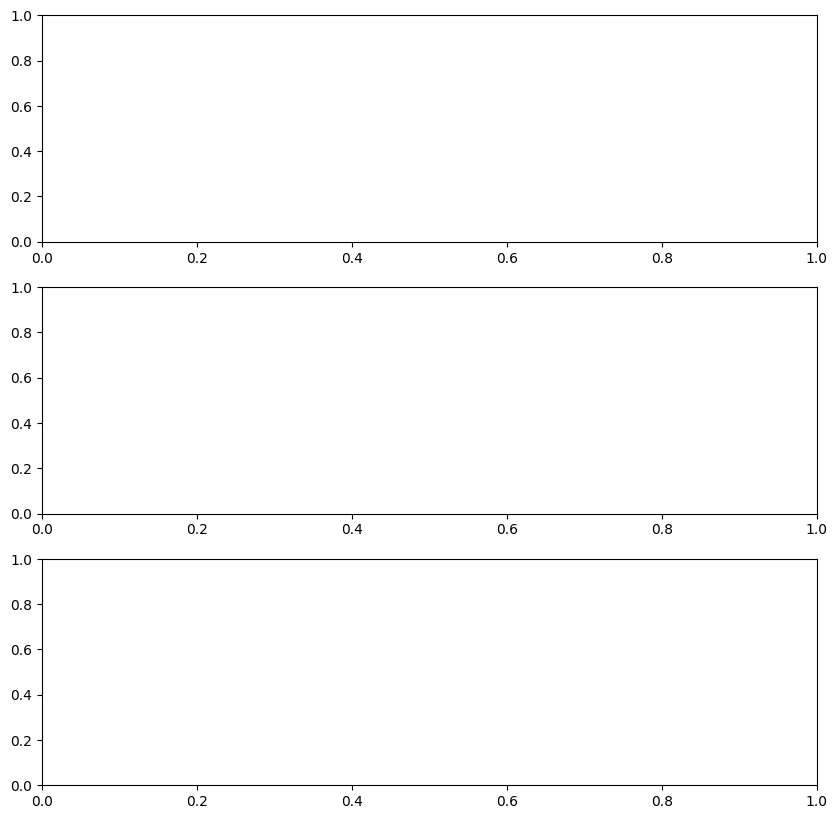

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# show the unitary evolution at 00, 11 and 01 for the target evolution and the actual evolution
ud_00 = column_0d[0]
ud_11 = column_1d[1]
ud_01 = column_0d[1]
uf_00 = lUad[:,0,0]
uf_11 = lUad[:,1,1]
uf_01 = lUad[:,0,1]
axes[0].plot(tlist, ud_00-ud_11, label="ud_delta")
axes[0].plot(tlist, ud_01, label="ud_01")
axes[1].plot(tlist, uf_00-uf_11, label="uf_delta")
axes[1].plot(tlist, uf_01, label="uf_01")

def demodulated_amplitude(signal, t_vals):
    wd_vals = np.array([drive_wd_interp(t) for t in t_vals])
    phi = np.zeros_like(t_vals)
    phi[1:] = np.cumsum(0.5 * (wd_vals[:-1] + wd_vals[1:]) * np.diff(t_vals))
    envelope = signal * np.exp(1j * phi)
    return np.sqrt(np.real(envelope)**2 + np.imag(envelope)**2)

# ud_delta = ud_00 - ud_11
# am_ud_delta = demodulated_amplitude(ud_delta, tlist_fid)
# am_ud_01 = demodulated_amplitude(ud_01, tlist_fid)

# axes[2].plot(tlist, ud_01-uf_01, label='amplitude deviance rr')
axes[2].plot(tlist, (ud_00-ud_11)-(uf_00-uf_11), label='amplitude deviance dd')
# ax_amp.plot(tlist_fid, am_ud_delta, label='amplitude(ud_00-ud_11)')
# ax_amp.plot(tlist_fid, am_ud_01, label='amplitude(ud_01)')
axes[2].set_xlabel('t (ns)')
axes[2].set_ylabel('demodulated amplitude')
axes[2].grid(True)
axes[2].legend()
plt.show()


infidelity gauss drag: 8.11e-01 pop: 2.36e-08
infidelity gauss no drag: 8.49e-01 pop: 1.46e-02


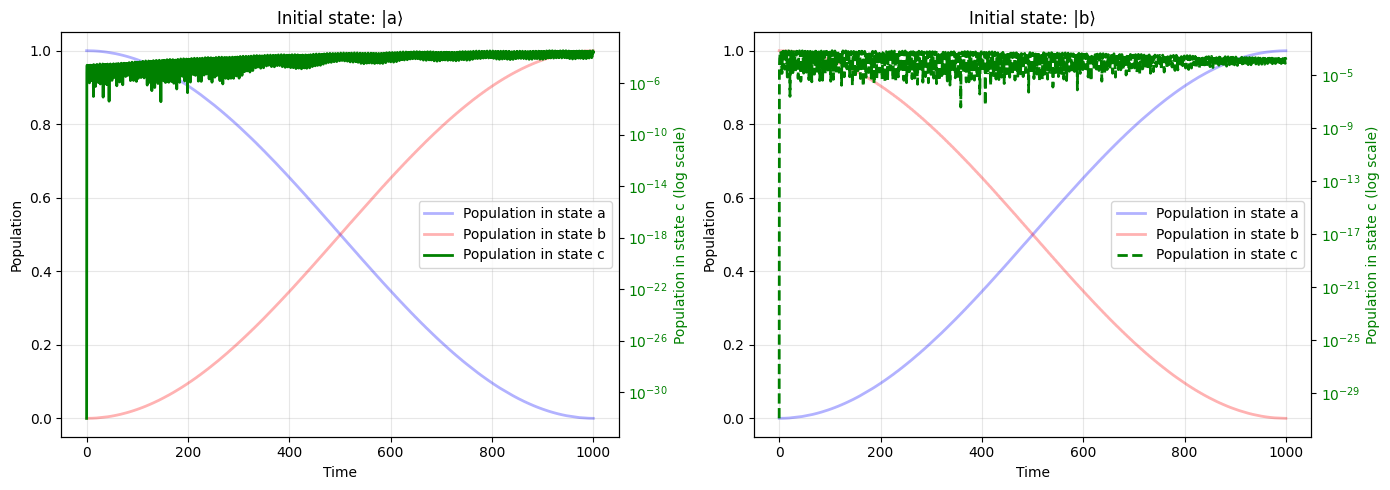

infidelity cos drive direct: 7.31e-01 pop: 2.07e-04


{'iswap_fidelity': np.float64(0.9997925222908026)}

In [ ]:
# engineered
tlist_fid = np.linspace(0, tg, 2300)
f_e = extract_fidelity(ht, tlist_fid)
fpop_e = extract_pop_fid(ht, tlist_fid, plot=False)['iswap_fidelity']
print(f"infidelity gauss drag: {(1-f_e):.2e} pop: {(1-fpop_e):.2e}")
# compare to an effective hamiltonian without drag
ht_nodrag, args = compute_htarget(tg, use_drag=False)
f_e_nodrag = extract_fidelity(ht_nodrag, tlist_fid)
fpop_e_nodrag = extract_pop_fid(ht_nodrag, tlist_fid, plot=False)['iswap_fidelity']
print(f"infidelity gauss no drag: {(1-f_e_nodrag):.2e} pop: {(1-fpop_e_nodrag):.2e}")
# verify that drag improves the engineered outcome
h_cos = [s.H0, [s.V1, lambda t, args: cos_amp * np.cos(cos_wd * t)]]
f_e_nodrag = extract_fidelity(h_cos, tlist_fid, sim = s)
fpop_e_nodrag = extract_pop_fid(h_cos, tlist_fid, s=s, plot=True, plot_c = True)
print(f"infidelity cos drive direct: {(1-f_e_nodrag):.2e} pop: {(1-fpop_e_nodrag['iswap_fidelity']):.2e}")
fpop_e_nodrag

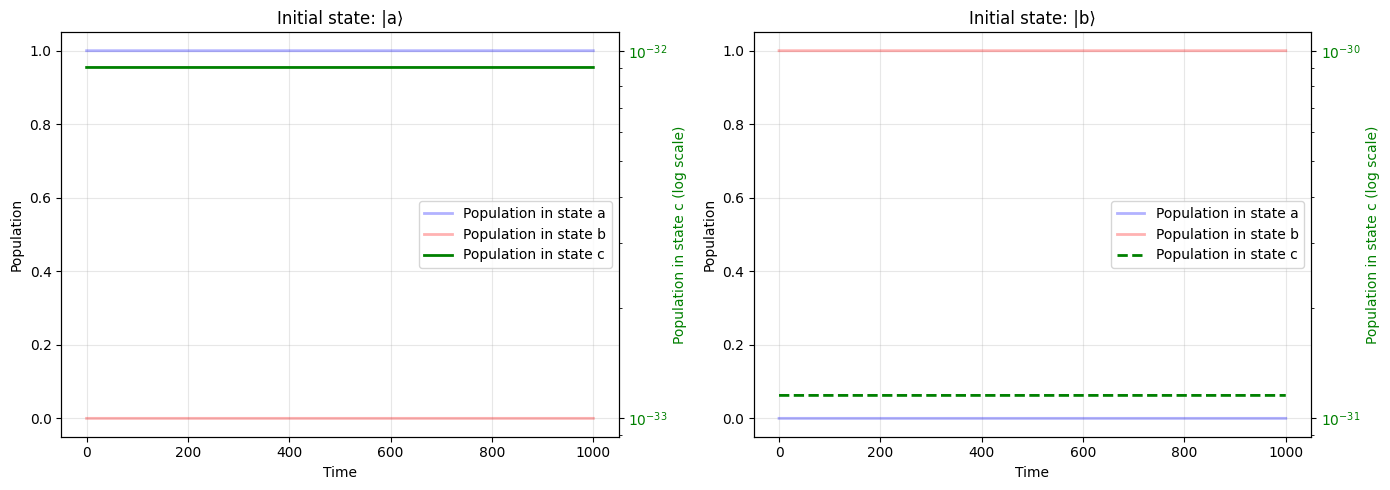

In [ ]:
#test without drive
h_test = [s.H0, 0]
fpop_e_nodrag = extract_pop_fid(h_test, tlist_fid, s=s, plot=True, plot_c = True)
